# NASA time series analysis demo
Using Sunpy to download data from CDAWeb and read CDF files, pandas to convert to dataframe and resample, and matplotlib to plot time series.

Example used here: Magnetic field data from *Wind* spacecraft

### Load libraries

Sunpy version used is `sunpy==6.0.4`

In [1]:
import glob
from sunpy.net import Fido, attrs as a
from sunpy.timeseries import TimeSeries
import warnings
from sunpy.util import SunpyUserWarning

# Suppress the specific SunpyUserWarning
warnings.filterwarnings("ignore", category=SunpyUserWarning)

c:\Users\spann\Documents\Code\space_turb_stats\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following packages are not installed:
['mpl-animators>=1.0.0']
To install sunpy with these dependencies use `pip install sunpy[visualization]` or `pip install sunpy[all]` for all extras. 
If you installed sunpy via conda, please report this to the community channel: https://matrix.to/#/#sunpy:openastronomy.org [sunpy.util.sysinfo]
2026-03-07 21:54:11 - sunpy - WARNING: SunpyUserWarning: Importing sunpy.visualization without its extra dependencies may result in errors.
The following packages are not installed:
['mpl-animators>=1.0.0']
To install sunpy with these dependencies use `pip install sunpy[visualization]` or `pip install sunpy[all]` for all extras. 
If you installed sunpy via conda, please report this to

In [2]:
!pip show sunpy

Name: sunpy
Version: 6.0.4
Summary: SunPy core package: Python for Solar Physics
Home-page: https://sunpy.org
Author: 
Author-email: The SunPy Community <sunpy@googlegroups.com>
License: 
Location: c:\Users\spann\Documents\Code\space_turb_stats\.venv\Lib\site-packages
Requires: astropy, numpy, packaging, parfive, pyerfa, requests
Required-by: 


### Download spacecraft data from CDAWeb
*Only run this section once! Once the data is downloaded, you don't need to download it again, so you should simply comment out the chunks below, up to the **Read data** section.*

To lookup the different dataset IDs available, you can use the form at https://cdaweb.gsfc.nasa.gov/index.html/ Tick the name of the spacecraft you want, hit submit, and you'll be a given a list of all the data products for that spacecraft. Set this as the `dataset_id` variable below.

In [ ]:
dataset_id = "PSP_FLD_L2_MAG_RTN"
# for Wind, use WI_H2_MFI

data_folder_path = "../data/raw/psp/" # adjust this path as needed

start_time = "2020-01-01 00:00"
end_time = "2020-01-01 23:59"

trange = a.Time(start_time, end_time)
dataset = a.cdaweb.Dataset(dataset_id)
result = Fido.search(trange, dataset)

# Get the list of available files in this timerange
print(result)

Results from 1 Provider:

2 Results from the CDAWEBClient:
Source: https://cdaweb.gsfc.nasa.gov/index.html

     Dataset              Start time               End time       
------------------ ----------------------- -----------------------
PSP_FLD_L2_MAG_RTN 2020-01-01 00:00:00.000 2020-01-01 02:03:18.000
PSP_FLD_L2_MAG_RTN 2020-01-01 10:53:17.000 2020-01-01 11:23:29.000




In [6]:
# Download these files
downloaded_files = Fido.fetch(result[0], path=data_folder_path)
print(downloaded_files)

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]






Files Downloaded: 100%|██████████| 2/2 [00:03<00:00,  1.70s/file]

['..\\data\\raw\\psp\\psp_fld_l2_mag_rtn_2020010100_v02.cdf', '..\\data\\raw\\psp\\psp_fld_l2_mag_rtn_2020010106_v02.cdf']


### Read data

In [4]:
dataset_id = "WI_H2_MFI"
data_folder_path = "../data/raw/wind/"

data_file_paths = glob.glob(data_folder_path + "*.cdf")

data_raw = TimeSeries(
    data_file_paths[0],
    concatenate=True
)

#### Get some information about the data (optional)

In [5]:
# data.columns
# data.units
# data.meta (This cuts off; better to use fn at end of this script)
# data.quicklook()  # Fun!
# data.truncate("2023/02/01 00:00", "2023/02/07 00:00").peek(columns=data.columns[0:3])

In [6]:
data_raw.units

{'BF1': Unit("nT"),
 'BGSE_0': Unit("nT"),
 'BGSE_1': Unit("nT"),
 'BGSE_2': Unit("nT"),
 'BGSM_0': Unit("nT"),
 'BGSM_1': Unit("nT"),
 'BGSM_2': Unit("nT"),
 'MAG_MODE': Unit(dimensionless),
 'RANGE': Unit(dimensionless),
 'SPC_MODE': Unit(dimensionless),
 'Time_PB5_0': Unit(dimensionless),
 'Time_PB5_1': Unit(dimensionless),
 'Time_PB5_2': Unit(dimensionless),
 'FLAG1_I': Unit(dimensionless),
 'FLAG1_O': Unit(dimensionless),
 'NUM1_PTS_I': Unit(dimensionless),
 'NUM1_PTS_O': Unit(dimensionless),
 'Time1_PB5_0': Unit(dimensionless),
 'Time1_PB5_1': Unit(dimensionless),
 'Time1_PB5_2': Unit(dimensionless)}

Convert to a pandas dataframe for easy manipulation


In [7]:
df_raw = data_raw.to_dataframe()
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 921437 entries, 2016-01-02 00:00:00.038000 to 2016-01-02 23:59:59.989000
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   BF1          919997 non-null  float32
 1   BGSE_0       919997 non-null  float32
 2   BGSE_1       919997 non-null  float32
 3   BGSE_2       919997 non-null  float32
 4   BGSM_0       919997 non-null  float32
 5   BGSM_1       919997 non-null  float32
 6   BGSM_2       919997 non-null  float32
 7   MAG_MODE     919997 non-null  float64
 8   RANGE        919997 non-null  float64
 9   SPC_MODE     919997 non-null  float64
 10  Time_PB5_0   919997 non-null  float64
 11  Time_PB5_1   919997 non-null  float64
 12  Time_PB5_2   919997 non-null  float64
 13  FLAG1_I      1440 non-null    float64
 14  FLAG1_O      1440 non-null    float64
 15  NUM1_PTS_I   1440 non-null    float64
 16  NUM1_PTS_O   1440 non-null    float64
 17  Time1_PB5_0  1440 n

In [8]:
# Check the cadence of the data - note this may vary during an interval
top_cadences = df_raw.index.to_series().diff().value_counts().head()
top_cadences

0 days 00:00:00.092000    918470
0 days 00:00:00.184000        92
0 days 00:00:00.018000        38
0 days 00:00:00.034000        38
0 days 00:00:00.091000        38
Name: count, dtype: int64

In [9]:
# Resample the data to your chosen cadence
chosen_cadence = "1s" # 1 hour cadence
df = df_raw.resample(chosen_cadence).mean()
# Check the cadence of the data after resampling
df.info()
# Make sure it's not too big before plotting!

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 86400 entries, 2016-01-02 00:00:00 to 2016-01-02 23:59:59
Freq: s
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   BF1          84669 non-null  float32
 1   BGSE_0       84669 non-null  float32
 2   BGSE_1       84669 non-null  float32
 3   BGSE_2       84669 non-null  float32
 4   BGSM_0       84669 non-null  float32
 5   BGSM_1       84669 non-null  float32
 6   BGSM_2       84669 non-null  float32
 7   MAG_MODE     84669 non-null  float64
 8   RANGE        84669 non-null  float64
 9   SPC_MODE     84669 non-null  float64
 10  Time_PB5_0   84669 non-null  float64
 11  Time_PB5_1   84669 non-null  float64
 12  Time_PB5_2   84669 non-null  float64
 13  FLAG1_I      1440 non-null   float64
 14  FLAG1_O      1440 non-null   float64
 15  NUM1_PTS_I   1440 non-null   float64
 16  NUM1_PTS_O   1440 non-null   float64
 17  Time1_PB5_0  1440 non-null   float64
 18  Tim

### Plot some data

In [10]:
df = df[20000:30000]

<Axes: >

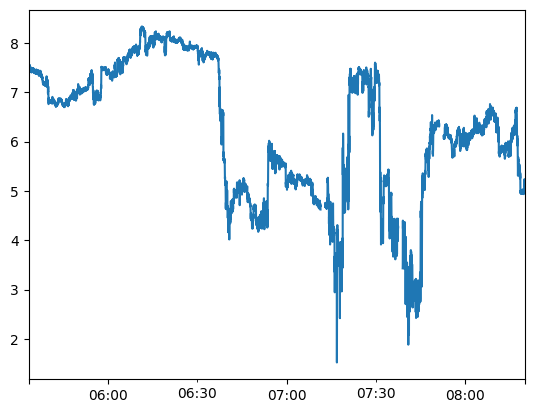

In [11]:
df.BF1.plot()

array([<Axes: xlabel='Date', ylabel='nT'>,
       <Axes: xlabel='Date', ylabel='nT'>,
       <Axes: xlabel='Date', ylabel='nT'>,
       <Axes: xlabel='Date', ylabel='nT'>], dtype=object)

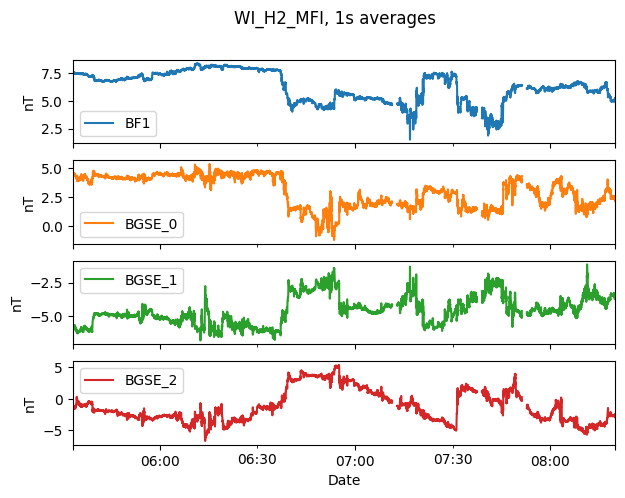

In [12]:
selected_columns = ["BF1", "BGSE_0", "BGSE_1", "BGSE_2"]
selected_time_range = ["2016-01-01", "2016-01-02"] # Change this to [:] to plot all data

df_to_plot = df.loc[selected_time_range[0]:selected_time_range[1], selected_columns]

df_to_plot.plot(
    subplots=True,
    figsize=(7, 5),
    title=f"{dataset_id}, {chosen_cadence} averages",
    xlabel="Date",
    ylabel="nT",
)

### Create artificial gaps
For testing the effect of missing data

<Axes: title={'center': '40.6% removed in chunks'}, xlabel='Time', ylabel='Bx [nT]'>

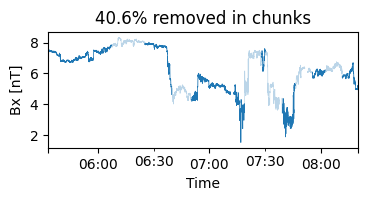

In [13]:
import sys
sys.path.append("..")

import src.ts_dashboard_utils as ts
import numpy as np
import pandas as pd

# Create a copy of the interval and remove data
interval_df = pd.DataFrame(df.BF1)
# Rename the column to 'data' for consistency with the functions
interval_df.columns = ['Bx']

prop_remove_chunks = 0.5

data_gapped_chunks, data_gapped_ind_chunks, prop_removed_chunks = (
    ts.remove_data(
        interval_df,
        prop_remove_chunks,
        chunks=np.random.randint(1, 10),
    )
)

# Calculate amount to remove uniformly
prop_remove_unif = 0

# Add the uniform gaps on top of chunks gaps
gapped_data, data_gapped_ind, prop_removed = ts.remove_data(
    data_gapped_chunks, prop_remove_unif
)
ax = interval_df.plot(
    figsize=(4, 1.5),
    legend=False,
    lw=0.5,
    title="Original data",
    ylabel="Bx [nT]",
    xlabel="Time",
    alpha=0.3,
    c="C0"
)
gapped_data.plot(
    ax=ax,
    lw=0.5,
    legend=False,
    title=f"{prop_removed*100:.1f}% removed in chunks",
    ylabel="Bx [nT]",
    xlabel="Time",
    c="C0"
)


<Axes: title={'center': '42.7% removed uniformly'}, xlabel='Time', ylabel='Bx [nT]'>

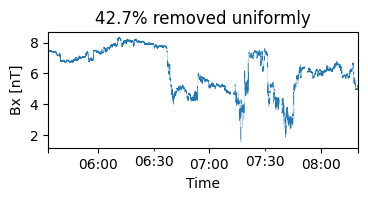

In [14]:
prop_remove_chunks = 0

data_gapped_chunks, data_gapped_ind_chunks, prop_removed_chunks = (
    ts.remove_data(
        interval_df,
        prop_remove_chunks,
        chunks=np.random.randint(1, 10),
    )
)

# Calculate amount to remove uniformly
prop_remove_unif = 0.4

# Add the uniform gaps on top of chunks gaps
gapped_data, data_gapped_ind, prop_removed = ts.remove_data(
    data_gapped_chunks, prop_remove_unif
)
ax = interval_df.plot(
    figsize=(4, 1.5),
    legend=False,
    title="Original data",
    ylabel="Bx [nT]",
    xlabel="Time",
    alpha=0.3,
    lw=0.5,
    c="C0"
)
gapped_data.plot(
    ax=ax,
    legend=False,
    title=f"{prop_removed*100:.1f}% removed uniformly",
    ylabel="Bx [nT]",
    xlabel="Time",
    lw=0.5,
    c="C0"
)

### Compute statistics

C:\Users\spann\AppData\Local\Temp\ipykernel_23420\3830870621.py:18: RuntimeWarning: divide by zero encountered in power
  plt.loglog(frequencies, frequencies**(-5/3)/500, 'r--', label='-5/3 slope')


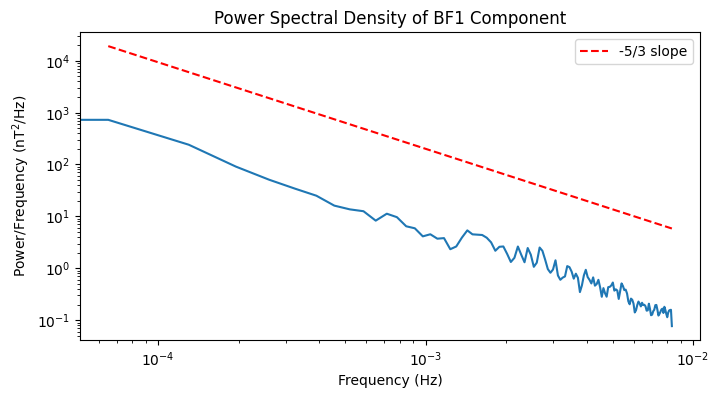

In [15]:
# Compute the power spectrum of the BF1 component of the data
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Select the BF1 component of the data
df_BF1 = df_to_plot["BF1"].dropna()
# Compute the power spectral density (PSD) using Welch's method
frequencies, psd = signal.welch(df_BF1, fs=1/60)

# Plot the PSD
plt.figure(figsize=(8, 4))
plt.loglog(frequencies, psd)
plt.title("Power Spectral Density of BF1 Component")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (nT$^2$/Hz)")
# Add a -5/3 slope line to indicate the Kolmogorov spectrum
plt.loglog(frequencies, frequencies**(-5/3)/500, 'r--', label='-5/3 slope')
plt.legend()
plt.show()

### *Improved metadata printing*

This function provides a way of extracting the metadata from the CDF file (variable names, resolution, etc.) and then printing it in a nicely-formatted table.

In [16]:
def print_metadata_table(data=None, max_width=80):
    """
    Parse and print data in a nice readable table format with text wrapping.
    Handles both formats:
    1. ("key": "[value1, value2]") format
    2. {'key': [value1, value2]} dictionary-like format

    Args:
        file_path (str, optional): Path to the file containing the data.
        data_string (str, optional): String containing the data.
        max_width (int, optional): Maximum width for the value column. Default is 80.
    """
    import re
    import textwrap
    import ast

    # Try to parse as a Python dictionary first
    try:
        data_dict = ast.literal_eval(data)
        # If successful, format the dictionary items
        matches = [(key, str(value)) for key, value in data_dict.items()]
    except (SyntaxError, ValueError):
        # If not a valid dictionary, try the old format
        pattern = r"\('([^']+)': '(\[[^\]]+\])'\)"
        matches = re.findall(pattern, data)

        if not matches:
            # Try another pattern for tuple-like format without the extra quotes
            pattern = r"\('([^']+)': (\[[^\]]+\])\)"
            matches = re.findall(pattern, data)

            if not matches:
                raise ValueError("No valid data found in the provided input")

    # Find the longest key for formatting
    max_key_length = max(len(key) for key, _ in matches)

    # Print the table header
    print(f"{'KEY'.ljust(max_key_length)} | VALUE")
    print("-" * max_key_length + "-+-" + "-" * max_width)

    # Print the table content
    for key, value in matches:
        # Clean up the value: handle both list and string representations
        if value.startswith("[") and value.endswith("]"):
            # Parse the list-like string
            try:
                # Try to parse as a Python list
                value_list = ast.literal_eval(value)
                if isinstance(value_list, list):
                    items = [str(item) for item in value_list]
                else:
                    items = [value.strip("[]")]
            except (SyntaxError, ValueError):
                # If parsing fails, handle as a string with commas
                cleaned_value = value.strip("[]")
                if "', '" in cleaned_value:
                    items = cleaned_value.split("', '")
                else:
                    items = [cleaned_value]
        else:
            items = [value]

        # Print each item with proper wrapping
        for i, item in enumerate(items):
            # For multi-line text, wrap each item
            wrapper = textwrap.TextWrapper(
                width=max_width,
                initial_indent="" if i == 0 else " " * (max_key_length + 3),
                subsequent_indent=" " * (max_key_length + 3),
            )

            # Clean the item text
            item_text = item.strip().strip("'\"")

            # Print first item with key, others with proper indentation
            if i == 0:
                wrapped_lines = wrapper.wrap(item_text)
                print(
                    f"{key.ljust(max_key_length)} | {wrapped_lines[0] if wrapped_lines else ''}"
                )
                for line in wrapped_lines[1:]:
                    print(line)
            else:
                wrapped_lines = wrapper.wrap(item_text)
                for line in wrapped_lines:
                    print(line)

        # Add a separator line between entries
        print("-" * max_key_length + "-+-" + "-" * max_width)


# Example usage:
# print_data_table(file_path="paste.txt", max_width=70)

In [17]:
# data.meta cuts off: this is better
full_metadata = data_raw.meta.find().metas[0]
metadata_to_print = str(full_metadata)

print_metadata_table(metadata_to_print)

KEY                        | VALUE
---------------------------+---------------------------------------------------------------------------------
Project                    | ISTP>International Solar-Terrestrial Physics
---------------------------+---------------------------------------------------------------------------------
Discipline                 | Space Physics>Heliospheric Science
---------------------------+---------------------------------------------------------------------------------
Source_name                | WIND>Wind Interplanetary Plasma Laboratory
---------------------------+---------------------------------------------------------------------------------
Software_version           | V05.00
---------------------------+---------------------------------------------------------------------------------
Data_type                  | H2>High-resolution Definitive Data
---------------------------+-----------------------------------------------------------------------------